Fair Modeling - Classification

In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error


In [2]:
pip install fairlearn # # 데이터 로드 torch sklearn matplotlib pandas numpy


In [3]:
from fairlearn.datasets import fetch_adult
# 데이터 로드
data = fetch_adult(as_frame=True)
if False:
  data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data")
  data.columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
                  "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

In [4]:
X, y, A = data.data.drop(columns=['sex']), data.target, data.data['sex']  # sensitibe attribute: 'sex'

In [5]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,30,United-States


In [6]:
y.head()

,class
0,<=50K
1,<=50K
2,>50K
3,>50K
4,<=50K


In [7]:
A.head()

,sex
0,Male
1,Male
2,Male
3,Male
4,Female


In [8]:
# One-Hot Encodeing & Zero imputation
X = pd.get_dummies(X).fillna(0) # zero imputation 은 training/testing 굳이 구분 필요 없죠.
# One-Hot Encodeing (Male=1, Female=0)
A = (A == 'Male').astype(int)
# One-Hot Encodeing (Male=1, Female=0)
y = pd.get_dummies(y, drop_first=True).astype(int)

In [9]:
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [10]:
A.head()

,sex
0,1
1,1
2,1
3,1
4,0


In [11]:
y.head()

,>50K
0,0
1,0
2,1
3,1
4,0


In [12]:
# 데이터 분리
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, A, test_size=0.2, random_state=42)


In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
X_train.astype(float)

array([[ 0.24612343, -0.42183886, -0.02983598, ...,  0.33733335,
        -0.04206007, -0.02086318],
       [ 0.97479439, -0.13860353, -1.58524788, ...,  0.33733335,
        -0.04206007, -0.02086318],
       [-0.33681334, -0.16104111, -0.41868896, ...,  0.33733335,
        -0.04206007, -0.02086318],
       ...,
       [-0.77401591,  0.57395334, -0.02983598, ...,  0.33733335,
        -0.04206007, -0.02086318],
       [ 0.53759181, -0.88219352,  0.359017  , ...,  0.33733335,
        -0.04206007, -0.02086318],
       [ 1.48486406, -0.1282718 ,  1.52557593, ...,  0.33733335,
        -0.04206007, -0.02086318]])

In [15]:
# Tensor 변환
X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train.values).float()
A_train_t = torch.tensor(A_train.values).float()
X_test_t = torch.tensor(X_test).float()
A_test_t = torch.tensor(A_test.values).float()
y_test_t = torch.tensor(y_test.values).float()

In [16]:
# Neural Network Model for Binary Classification
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
            )
    def forward(self, x):
        return self.fc(x)


Fair Modeling
- Demographic Parity: 예측값 평균의 그룹 간 차이 최소화
- Equal Opportunity: 실제 Positive에서 TPR 차이 최소화
- Equalized Odds: TPR과 FPR 차이 최소화
- Individual Fairness: 유사 데이터 간의 예측 차이 최소화 (주로 이론용)


In [17]:
def disparate_impact_loss(preds, A):
  # 공정성 분야에서는 일반적으로 이진 분류의 Positive class(예측=1)의 비율을 나타내는 용어로 Selection Rate라는 용어를 많이 사용
  selection_rate_0 = preds[A == 0].mean() # Sensitive Group A가 0인 그룹의 평균 예측확률 평균값(mean of predictied probabilities)
  selection_rate_1 = preds[A == 1].mean() # Sensitive Group A가 1인 그룹의 평균 예측확률 평균값(mean of predictied probabilities)

  # selection_rate가 낮은 그룹 0 또는 1을 분자로 설정하여 0으로 나누는 문제 방지
  min_selection_rate = torch.min(selection_rate_0, selection_rate_1)
  max_selection_rate = torch.max(selection_rate_0, selection_rate_1)
  epsilon = 1e-6 # 나눗셈이 불가능한 경우 방지 (epsilon 추가)

  # 두 그룹 간의 selection rate 비율(ratio) 계산
  di_ratio = min_selection_rate / (max_selection_rate + epsilon) # 0~1사이에 오도록 하기 위헤 큰 값을 분모로 설정, 무한대 방지, 결국 목적은 공정하게 하는 것.

  # 완전 공정한 상태는 di_ratio가 1여야만 함
  # loss는 줄여야 함, 작을수록 공정하게 하기 위해 1에서 빼줌, 즉 최고 공정하면 0이면 좋아
  # di_ratio 1, 줄여야 돼, loss_fair로 쓰자)
  loss_fair = torch.abs(1.0 - di_ratio)
  return loss_fair



- Custom Loss Function: 미분가능(differentiable)하고, 연속적이고, Scalar 값으로 출력
  - torch.mean, torch.sum, torch.abs, torch.min, torch.max 사용 O
  - 사용자 정의 loss를 만들 땐 torch.round, 조건문(if) 등을 직접적으로 사용 X
  - 필요 시 torch.sigmoid나 torch.softmax 등 미분 가능한 함수로 유사한 효과를 냅니다.

In [18]:
criterion = nn.BCELoss()
model_fair = SimpleNN(X_train.shape[1]) # 먼저 정의
optimizer_fair = optim.Adam(model_fair.parameters(), lr=0.01) # 모델 다음 정의

model_fair.train()
for epoch in range(100):
    optimizer_fair.zero_grad() # gradient 초기화
    preds = model_fair(X_train_t)

    loss_acc = criterion(preds, y_train_t) # 기본 손실 함수
    loss_fair = disparate_impact_loss(preds, A_train_t) # Disparate Impact 공정성 손실 추가 (lambda로 강도 조정 가능)

    total_loss = loss_acc + 0.5 * loss_fair  # 0.5는 공정성 강도
    print(f"Epoch {epoch+1} | total_loss: {total_loss.item():.4f}, loss_acc: {loss_acc.item():.4f}, loss_fair: {loss_fair.item():.4f}")
    total_loss.backward() # gradient 계산
    optimizer_fair.step() # gradient 기반 모델 업데이트

Epoch 1 | total_loss: 0.7082, loss_acc: 0.7072, loss_fair: 0.0021
Epoch 2 | total_loss: 0.6783, loss_acc: 0.6349, loss_fair: 0.0869
Epoch 3 | total_loss: 0.6420, loss_acc: 0.5842, loss_fair: 0.1157
Epoch 4 | total_loss: 0.6073, loss_acc: 0.5471, loss_fair: 0.1204
Epoch 5 | total_loss: 0.5744, loss_acc: 0.5197, loss_fair: 0.1095
Epoch 6 | total_loss: 0.5422, loss_acc: 0.4994, loss_fair: 0.0855
Epoch 7 | total_loss: 0.5094, loss_acc: 0.4852, loss_fair: 0.0485
Epoch 8 | total_loss: 0.4778, loss_acc: 0.4765, loss_fair: 0.0027
Epoch 9 | total_loss: 0.4659, loss_acc: 0.4627, loss_fair: 0.0064
Epoch 10 | total_loss: 0.4580, loss_acc: 0.4469, loss_fair: 0.0221
Epoch 11 | total_loss: 0.4525, loss_acc: 0.4364, loss_fair: 0.0323
Epoch 12 | total_loss: 0.4434, loss_acc: 0.4304, loss_fair: 0.0259
Epoch 13 | total_loss: 0.4305, loss_acc: 0.4287, loss_fair: 0.0036
Epoch 14 | total_loss: 0.4475, loss_acc: 0.4308, loss_fair: 0.0334
Epoch 15 | total_loss: 0.4447, loss_acc: 0.4281, loss_fair: 0.0333
Epoc

In [19]:
criterion = nn.BCELoss()
model_base = SimpleNN(X_train.shape[1]) # 먼저 정의
optimizer_base = optim.Adam(model_base.parameters(), lr=0.01) # 모델 다음 정의

model_base.train()
for epoch in range(100):
    optimizer_base.zero_grad() # gradient 초기화
    preds = model_base(X_train_t)

    loss_acc = criterion(preds, y_train_t) # 기본 손실 함수
    total_loss = loss_acc
    print(f"Epoch {epoch+1} | total_loss: {total_loss.item():.4f}, loss_acc: {loss_acc.item():.4f}")
    total_loss.backward() # gradient 계산
    optimizer_base.step() # gradient 기반 모델 업데이트

Epoch 1 | total_loss: 0.7057, loss_acc: 0.7057
Epoch 2 | total_loss: 0.6500, loss_acc: 0.6500
Epoch 3 | total_loss: 0.6008, loss_acc: 0.6008
Epoch 4 | total_loss: 0.5564, loss_acc: 0.5564
Epoch 5 | total_loss: 0.5161, loss_acc: 0.5161
Epoch 6 | total_loss: 0.4800, loss_acc: 0.4800
Epoch 7 | total_loss: 0.4486, loss_acc: 0.4486
Epoch 8 | total_loss: 0.4225, loss_acc: 0.4225
Epoch 9 | total_loss: 0.4016, loss_acc: 0.4016
Epoch 10 | total_loss: 0.3855, loss_acc: 0.3855
Epoch 11 | total_loss: 0.3733, loss_acc: 0.3733
Epoch 12 | total_loss: 0.3643, loss_acc: 0.3643
Epoch 13 | total_loss: 0.3578, loss_acc: 0.3578
Epoch 14 | total_loss: 0.3531, loss_acc: 0.3531
Epoch 15 | total_loss: 0.3500, loss_acc: 0.3500
Epoch 16 | total_loss: 0.3480, loss_acc: 0.3480
Epoch 17 | total_loss: 0.3471, loss_acc: 0.3471
Epoch 18 | total_loss: 0.3469, loss_acc: 0.3469
Epoch 19 | total_loss: 0.3471, loss_acc: 0.3471
Epoch 20 | total_loss: 0.3472, loss_acc: 0.3472
Epoch 21 | total_loss: 0.3470, loss_acc: 0.3470
E

In [20]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 평가 모드 전환
model_base.eval()
model_fair.eval()

# 테스트 데이터 예측
with torch.no_grad():
    y_pred_base = (model_base(X_test_t).numpy() >= 0.5).astype(int)
    y_pred_fair = (model_fair(X_test_t).numpy() >= 0.5).astype(int)

# Accuracy 계산
acc_base = accuracy_score(y_test, y_pred_base)
acc_fair = accuracy_score(y_test, y_pred_fair)
print(f"Base Model Accuracy: {acc_base:.4f}")
print(f"Fair Model Accuracy: {acc_fair:.4f}")


Base Model Accuracy: 0.8598
Fair Model Accuracy: 0.8320


In [21]:
# Fairness 평가 (Disparate Impact)
# 그룹별 정확도 및 공정성(Selection Rate) 평가
metrics = {
    'accuracy': accuracy_score,       # sklearn accuracy_score 사용
    'selection_rate': selection_rate
}
mf_base = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred_base, sensitive_features=A_test)
mf_fair = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred_fair, sensitive_features=A_test)


In [22]:
mf_fair.by_group['accuracy']


,accuracy
sex,
0,0.890117
1,0.802949


In [23]:
mf_fair.by_group['selection_rate']


,selection_rate
sex,
0,0.171578
1,0.162801


Fairness (Selection Rate) 비교
기본 모델:
 sex
0    0.079190
1    0.260789
Name: selection_rate, dtype: float64
공정성 적용 모델:
 sex
0    0.171578
1    0.162801
Name: selection_rate, dtype: float64


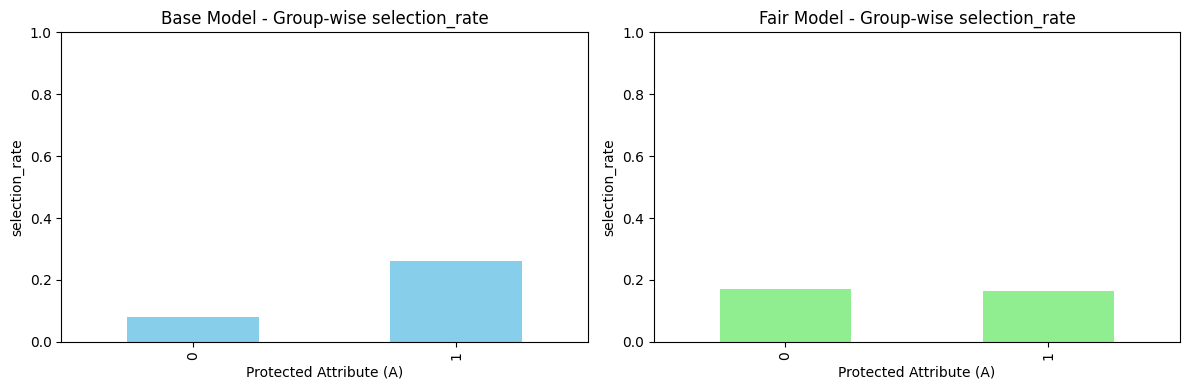

In [24]:
# 시각화 (selection rate 비교)
print("Fairness (Selection Rate) 비교")
print("기본 모델:\n", mf_base.by_group['selection_rate'])
print("공정성 적용 모델:\n", mf_fair.by_group['selection_rate'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

mf_base.by_group['selection_rate'].plot.bar(ax=ax[0], color='skyblue')
ax[0].set_ylim(0,1)
ax[0].set_title('Base Model - Group-wise selection_rate')
ax[0].set_xlabel('Protected Attribute (A)')
ax[0].set_ylabel('selection_rate')

mf_fair.by_group['selection_rate'].plot.bar(ax=ax[1], color='lightgreen')
ax[1].set_ylim(0,1)
ax[1].set_title('Fair Model - Group-wise selection_rate')
ax[1].set_xlabel('Protected Attribute (A)')
ax[1].set_ylabel('selection_rate')

plt.tight_layout()
plt.show()


Fairness (accuracy) 비교
기본 모델:
 sex
0    0.935850
1    0.821686
Name: accuracy, dtype: float64
공정성 적용 모델:
 sex
0    0.890117
1    0.802949
Name: accuracy, dtype: float64


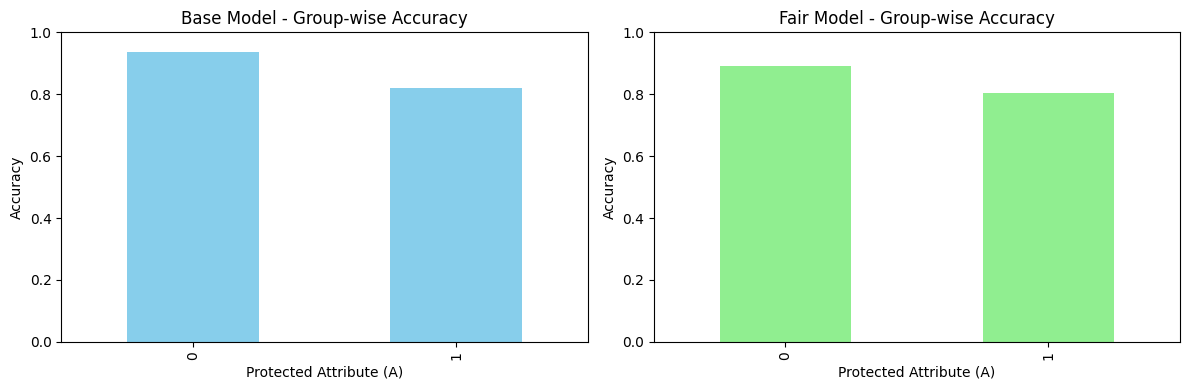

In [25]:
# 시각화 (Accuracy 비교)
print("Fairness (accuracy) 비교")
print("기본 모델:\n", mf_base.by_group['accuracy'])
print("공정성 적용 모델:\n", mf_fair.by_group['accuracy'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

mf_base.by_group['accuracy'].plot.bar(ax=ax[0], color='skyblue')
ax[0].set_ylim(0,1)
ax[0].set_title('Base Model - Group-wise Accuracy')
ax[0].set_xlabel('Protected Attribute (A)')
ax[0].set_ylabel('Accuracy')

mf_fair.by_group['accuracy'].plot.bar(ax=ax[1], color='lightgreen')
ax[1].set_ylim(0,1)
ax[1].set_title('Fair Model - Group-wise Accuracy')
ax[1].set_xlabel('Protected Attribute (A)')
ax[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [26]:
def disparate_impact_loss(preds, A):
  min_selection_rate = torch.min(preds[A == 0].mean(), preds[A == 1].mean())
  max_selection_rate = torch.max(preds[A == 0].mean(), preds[A == 1].mean())
  epsilon = 1e-6
  di_ratio = min_selection_rate / (max_selection_rate + epsilon)
  loss_fair = torch.abs(1.0 - di_ratio)
  return loss_fair

def demographic_parity_loss(preds, A):
  loss_fair = torch.abs(preds[A==0].mean() - preds[A==1].mean())
  return loss_fair

def train_model(fairness=None, lambda_fair=0.5, epochs=30):
    model = SimpleNN(X_train.shape[1])
    criterion = nn.BCELoss() # Binary Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X_train_t)
        loss = criterion(preds, y_train_t)

        if fairness == 'di':
            loss += lambda_fair * disparate_impact_loss(preds, A_train.values)
        elif fairness == 'dp':
            loss += lambda_fair * demographic_parity_loss(preds, A_train.values)
        loss.backward()
        optimizer.step()
    return model

models = {
    'Baseline': train_model(fairness=None),
    'Disparate Impact': train_model(fairness='di'),
    'Demographic Parity': train_model(fairness='dp'),
}


✅ Baseline 모델 그룹별 평가 결과:
     accuracy  selection_rate
sex                          
0    0.931553        0.082873
1    0.810782        0.275994

✅ Disparate Impact 모델 그룹별 평가 결과:
     accuracy  selection_rate
sex                          
0    0.876304        0.183548
1    0.795116        0.181078

✅ Demographic Parity 모델 그룹별 평가 결과:
     accuracy  selection_rate
sex                          
0    0.896562        0.157766
1    0.797266        0.167255


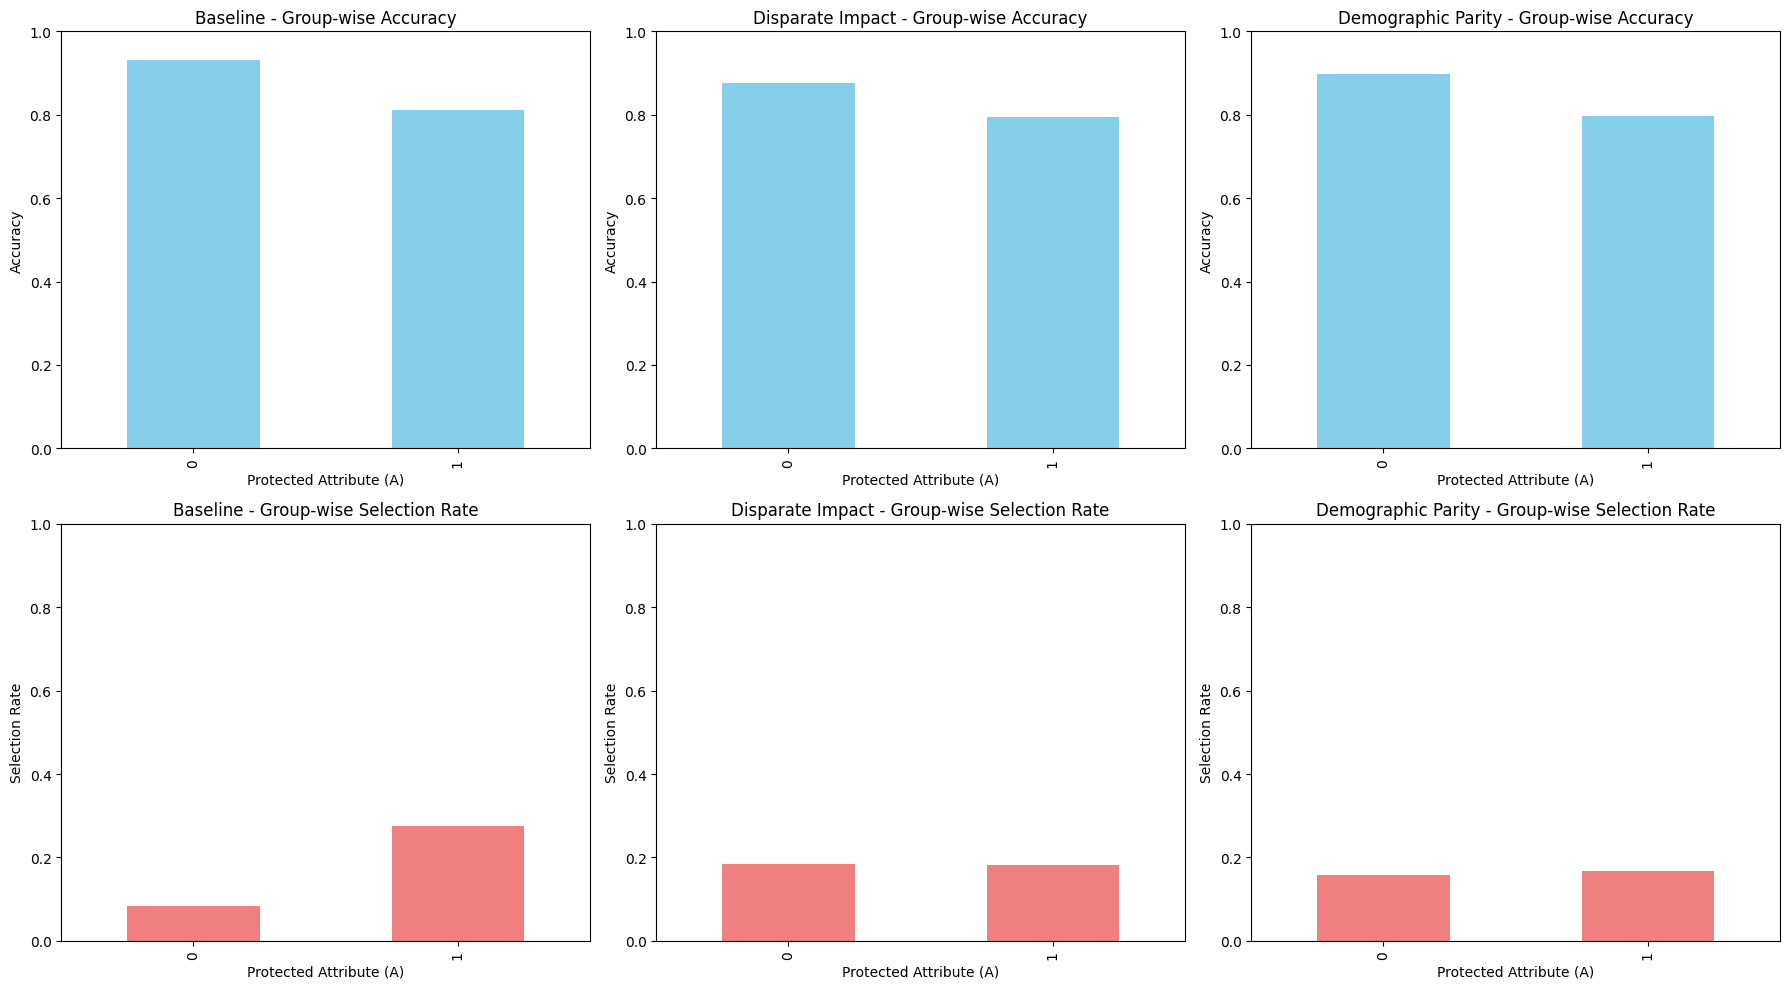

In [27]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 각 모델을 평가 모드로 전환하고 테스트셋 예측
preds_dict = {}
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t).numpy() >= 0.5).astype(int)
        preds_dict[name] = preds

# 그룹별 성능 평가 (정확도, selection_rate)
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate
}

results = {}
for name, y_pred in preds_dict.items():
    mf = MetricFrame(metrics=metrics,
                     y_true=y_test,
                     y_pred=y_pred,
                     sensitive_features=A_test)
    results[name] = mf.by_group

# 결과 출력
for name, res in results.items():
    print(f"\n✅ {name} 모델 그룹별 평가 결과:")
    print(res)

# 시각화 코드 (정확도 & Selection Rate 비교)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, res) in enumerate(results.items()):
    res['accuracy'].plot.bar(ax=axes[0, i], color='skyblue', ylim=[0, 1])
    axes[0, i].set_title(f'{name} - Group-wise Accuracy')
    axes[0, i].set_xlabel('Protected Attribute (A)')
    axes[0, i].set_ylabel('Accuracy')

    res['selection_rate'].plot.bar(ax=axes[1, i], color='lightcoral', ylim=[0, 1])
    axes[1, i].set_title(f'{name} - Group-wise Selection Rate')
    axes[1, i].set_xlabel('Protected Attribute (A)')
    axes[1, i].set_ylabel('Selection Rate')

plt.tight_layout()
plt.show()


수행해보세요.
- 성별(Sex): 대표적으로 가장 많이 쓰이는 민감한 속성
- 인종(Race): 흑인, 백인 등 인종 차이를 보기 위한 변수
- 나이(Age): 특히 나이를 젊은층과 고령층으로 나눠 공정성 평가 시 사용
- 국적(Native-country): 출신국가에 따른 차별성 분석 시 사용 가능

- 실습을 위한 대표적 Python 라이브러리 소개
  - AI Fairness 360 (IBM)
    - 다양한 fairness metrics 및 알고리즘 제공
    - URL: https://aif360.mybluemix.net/
  - Fairlearn (Microsoft)
    - sklearn 및 PyTorch와 쉽게 결합 가능
    - URL: https://fairlearn.org